Using device: cuda
Keys in .mat file:
dict_keys(['__header__', '__version__', '__globals__', 's_train', 'u_train'])
Raw u_train shape: (1250, 200, 200)
Raw s_train shape: (1250, 200, 1)
Processed branch input shape: (1250, 200)
Processed output field shape: (1250, 200, 200)


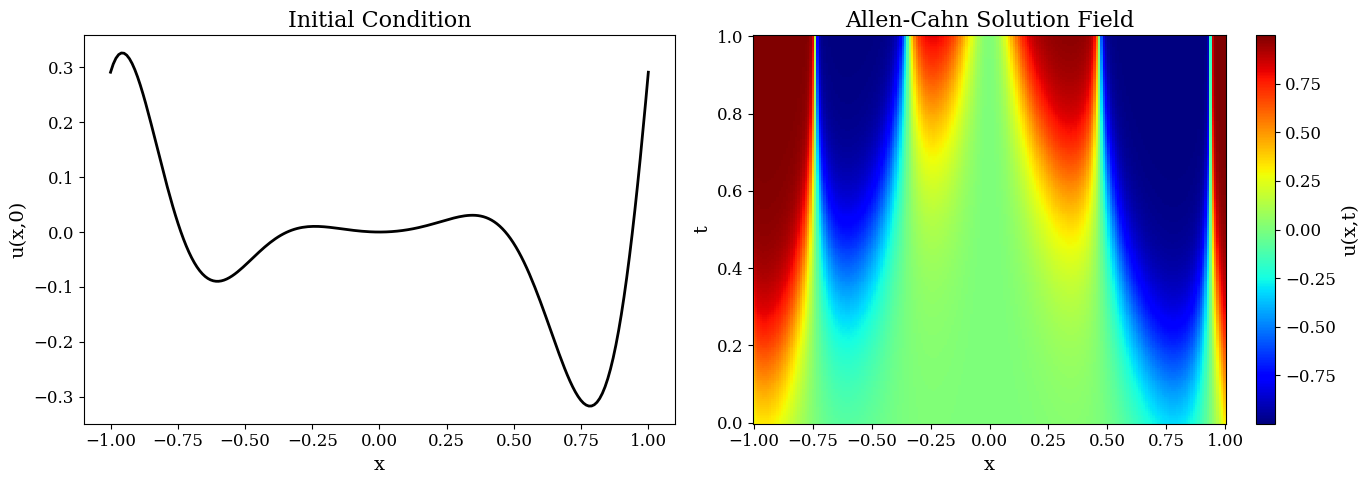

X_train: (1000, 200)
X_test : (250, 200)
y_train: (1000, 200, 200)
y_test : (250, 200, 200)

Training FEDONet...

[FEDONet] Epoch [1/5000] | Train Loss: 0.415171429157 | Test Loss: 0.365752226591 | LR: 0.001000
[FEDONet] Epoch [1001/5000] | Train Loss: 0.001922235137 | Test Loss: 0.002655073956 | LR: 0.000949
[FEDONet] Epoch [2001/5000] | Train Loss: 0.001359494061 | Test Loss: 0.002068674849 | LR: 0.000900
[FEDONet] Epoch [3001/5000] | Train Loss: 0.001189578059 | Test Loss: 0.001843048342 | LR: 0.000854
[FEDONet] Epoch [4001/5000] | Train Loss: 0.001137929011 | Test Loss: 0.001779515997 | LR: 0.000810
[FEDONet] Epoch [5000/5000] | Train Loss: 0.001090428767 | Test Loss: 0.001748486910 | LR: 0.000768

Training Vanilla DeepONet...

[Vanilla] Epoch [1/5000] | Train Loss: 0.426952733755 | Test Loss: 0.421030644655 | LR: 0.001000
[Vanilla] Epoch [1001/5000] | Train Loss: 0.013499114163 | Test Loss: 0.013700599298 | LR: 0.000949
[Vanilla] Epoch [2001/5000] | Train Loss: 0.008495323330 | Te

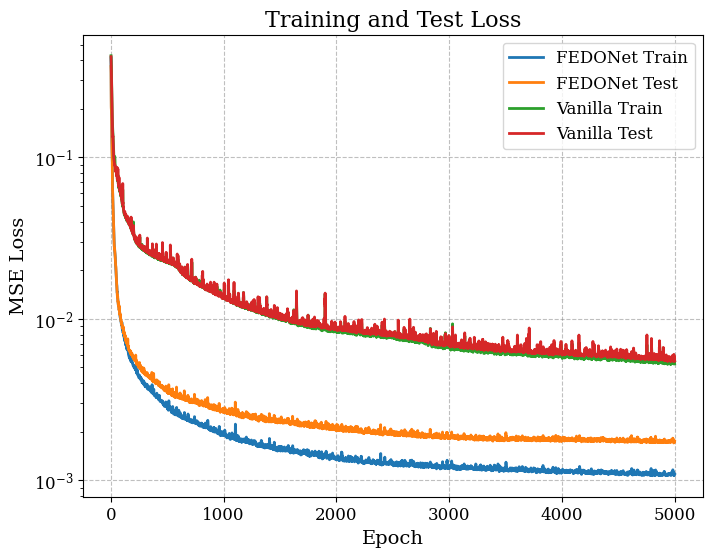


=== CLEAN TEST PERFORMANCE ===
FEDONet : {'rel_l2': 0.058570243418216705, 'mse': 0.0017484851414337754, 'mae': 0.019163990393280983, 'ssim': 0.961145969014298}
Vanilla : {'rel_l2': 0.10985320806503296, 'mse': 0.005474328529089689, 'mae': 0.04067905247211456, 'ssim': 0.880424027051356}
Noise = 0% | FEDONet RelL2 = 0.058570 | Vanilla RelL2 = 0.109853
Noise = 1% | FEDONet RelL2 = 0.058619 | Vanilla RelL2 = 0.109877
Noise = 2% | FEDONet RelL2 = 0.058957 | Vanilla RelL2 = 0.109965
Noise = 5% | FEDONet RelL2 = 0.060387 | Vanilla RelL2 = 0.110385
Noise = 10% | FEDONet RelL2 = 0.065256 | Vanilla RelL2 = 0.112417
Noise = 20% | FEDONet RelL2 = 0.079781 | Vanilla RelL2 = 0.118000


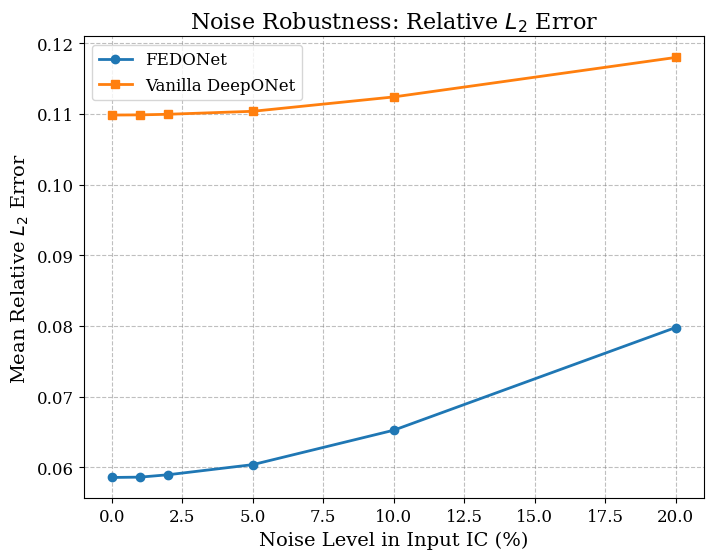

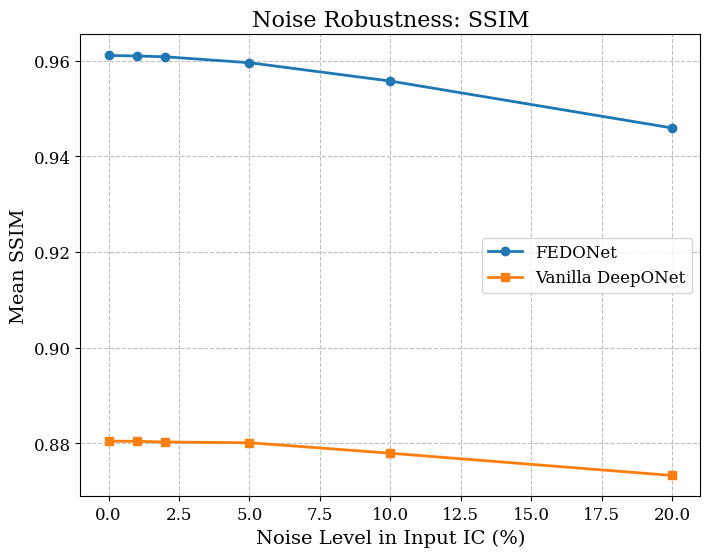

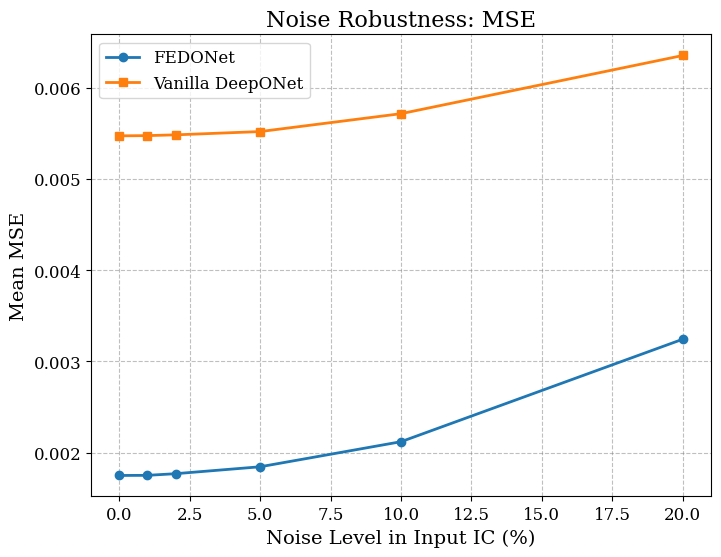

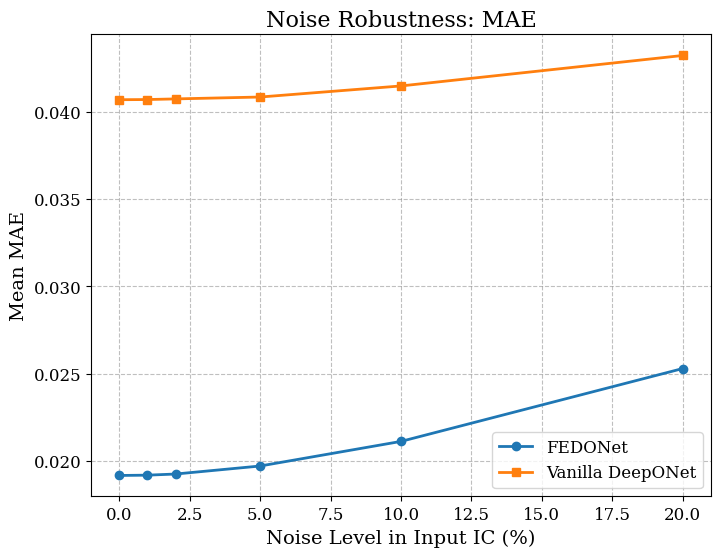


=== NOISE ROBUSTNESS TABLE ===
+---------+-----------------+-----------------+----------------+----------------+---------------+---------------+---------------+---------------+
| Noise   |   FEDONet RelL2 |   Vanilla RelL2 |   FEDONet SSIM |   Vanilla SSIM |   FEDONet MSE |   Vanilla MSE |   FEDONet MAE |   Vanilla MAE |
+=========+=================+=================+================+================+===============+===============+===============+===============+
| 0%      |        0.05857  |        0.109853 |       0.961146 |       0.880424 |    0.00174848 |    0.00547433 |     0.019164  |     0.0406791 |
+---------+-----------------+-----------------+----------------+----------------+---------------+---------------+---------------+---------------+
| 1%      |        0.058619 |        0.109877 |       0.961032 |       0.880392 |    0.00174997 |    0.00547689 |     0.0191818 |     0.0406886 |
+---------+-----------------+-----------------+----------------+----------------+-----------

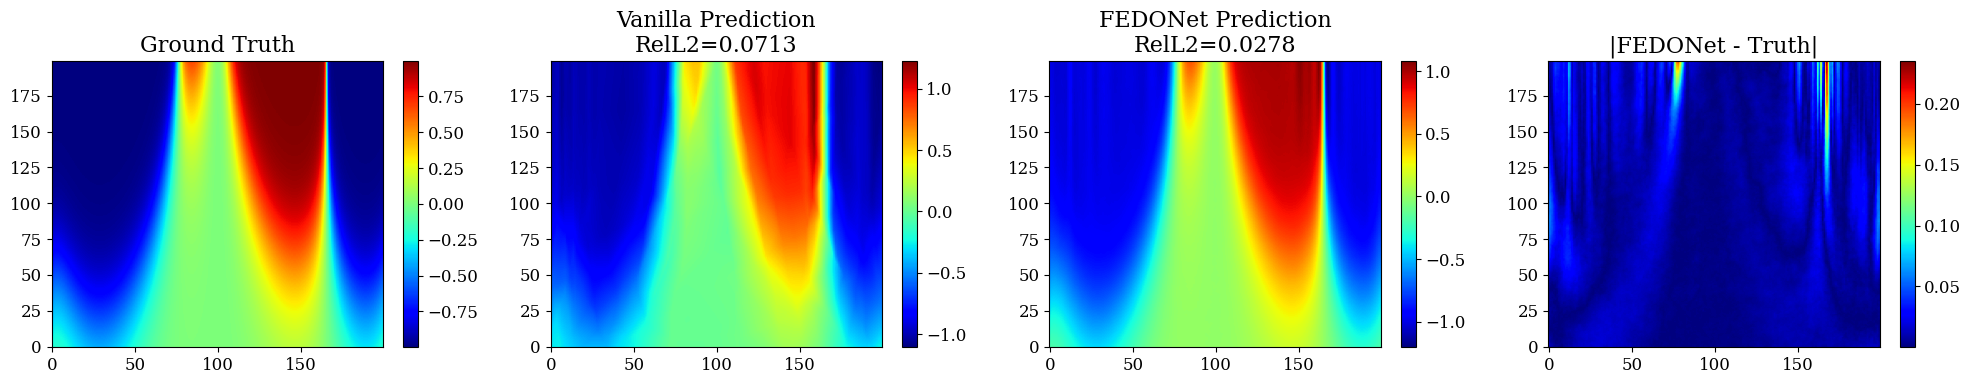

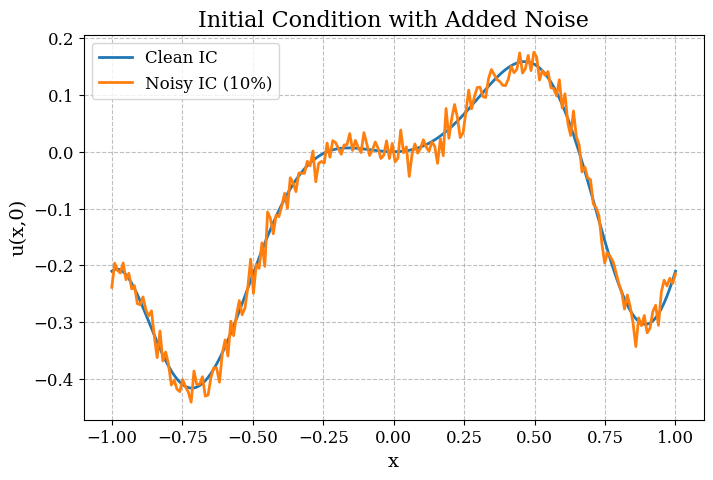


=== PERFORMANCE DROP FROM CLEAN TO 10% NOISE (sampled through robustness curves) ===
FEDONet  Clean RelL2: 0.058570
FEDONet  10%  RelL2: 0.065256
Vanilla  Clean RelL2: 0.109853
Vanilla  10%  RelL2: 0.112417


In [2]:
# ============================================================
# ALLEN-CAHN: FEDONet vs Vanilla DeepONet
# Noise Robustness to Input Initial Condition
# End-to-end clean code
# ============================================================

import os
import random
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
import matplotlib as mpl

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from skimage.metrics import structural_similarity as ssim
from tabulate import tabulate

# ============================================================
# 1. REPRODUCIBILITY
# ============================================================
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ============================================================
# 2. HYPERPARAMETERS
# ============================================================
num_epochs = 5000
batch_size = 128
learning_rate = 1e-3

n_train_total = 1250
test_size = 0.2

grid_size = 200
latent_dim = 100
fourier_mapping_size = 256

# ============================================================
# 3. PLOT SETTINGS
# ============================================================
def set_plot_params():
    mpl.rcParams['figure.figsize'] = (8, 6)
    mpl.rcParams['figure.dpi'] = 100
    mpl.rcParams['savefig.dpi'] = 300

    mpl.rcParams['font.family'] = 'serif'
    mpl.rcParams['font.size'] = 12
    mpl.rcParams['axes.titlesize'] = 16
    mpl.rcParams['axes.labelsize'] = 14
    mpl.rcParams['xtick.labelsize'] = 12
    mpl.rcParams['ytick.labelsize'] = 12
    mpl.rcParams['legend.fontsize'] = 12

    mpl.rcParams['lines.linewidth'] = 2
    mpl.rcParams['lines.markersize'] = 6

    mpl.rcParams['contour.negative_linestyle'] = 'solid'
    mpl.rcParams['grid.linestyle'] = '--'
    mpl.rcParams['grid.color'] = 'gray'
    mpl.rcParams['grid.alpha'] = 0.5

    mpl.rcParams['image.cmap'] = 'plasma'

set_plot_params()

# ============================================================
# 4. METRICS
# ============================================================
def relative_l2_error_sample(y_true, y_pred):
    return np.linalg.norm(y_true - y_pred) / (np.linalg.norm(y_true) + 1e-12)

def relative_l2_error_batch(y_true, y_pred):
    errs = []
    for i in range(y_true.shape[0]):
        errs.append(relative_l2_error_sample(y_true[i], y_pred[i]))
    return float(np.mean(errs))

def compute_mse_batch(y_true, y_pred):
    return float(np.mean((y_true - y_pred) ** 2))

def compute_mae_batch(y_true, y_pred):
    return float(np.mean(np.abs(y_true - y_pred)))

def compute_ssim_batch(y_true, y_pred):
    vals = []
    for i in range(y_true.shape[0]):
        dr = y_true[i].max() - y_true[i].min()
        if dr < 1e-12:
            dr = 1.0
        vals.append(ssim(y_true[i], y_pred[i], data_range=dr))
    return float(np.mean(vals))

# ============================================================
# 5. LOAD DATA
# ============================================================
data = scipy.io.loadmat("Allen_Cahn_4_terms_more_resolution.mat")

print("Keys in .mat file:")
print(data.keys())

u_data = data["u_train"][:n_train_total]   # expected full solution, shape (N, 200, 200)
s_data = data["s_train"][:n_train_total]   # expected IC or related input

print("Raw u_train shape:", u_data.shape)
print("Raw s_train shape:", s_data.shape)

# ------------------------------------------------------------
# Robust extraction of branch input (initial condition)
# ------------------------------------------------------------
# We want:
#   X_input : shape (N, 200)
#   Y_field : shape (N, 200, 200)
#
# Cases handled:
#   1) s_train already shape (N, 200)
#   2) s_train shape (N, 200, 1)
#   3) s_train shape (N, 1, 200)
#   4) s_train shape (N, 200, 200) and IC is one boundary slice
# ------------------------------------------------------------

if s_data.ndim == 2:
    X_input = s_data

elif s_data.ndim == 3:
    if s_data.shape[1] == grid_size and s_data.shape[2] == 1:
        X_input = s_data[:, :, 0]
    elif s_data.shape[1] == 1 and s_data.shape[2] == grid_size:
        X_input = s_data[:, 0, :]
    elif s_data.shape[1] == grid_size and s_data.shape[2] == grid_size:
        # choose first temporal slice as IC candidate
        # if your orientation is opposite, switch to s_data[:, 0, :]
        X_input = s_data[:, :, 0]
    else:
        raise ValueError(f"Unsupported s_train shape: {s_data.shape}")
else:
    raise ValueError(f"Unsupported s_train ndim: {s_data.ndim}")

Y_field = u_data

if X_input.shape[1] != grid_size:
    raise ValueError(f"Branch input must have length {grid_size}, got {X_input.shape}")

if Y_field.shape[1:] != (grid_size, grid_size):
    raise ValueError(f"Output field must have shape (N, {grid_size}, {grid_size}), got {Y_field.shape}")

print("Processed branch input shape:", X_input.shape)
print("Processed output field shape:", Y_field.shape)

# ============================================================
# 6. VISUALIZE ONE SAMPLE
# ============================================================
sample_idx = random.randint(0, X_input.shape[0] - 1)

x = np.linspace(-1, 1, grid_size)
t = np.linspace(0, 1, grid_size)
XX, TT = np.meshgrid(x, t)

fig = plt.figure(figsize=(14, 5))

ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(x, X_input[sample_idx], color='k')
ax1.set_xlabel('x')
ax1.set_ylabel('u(x,0)')
ax1.set_title('Initial Condition')

ax2 = fig.add_subplot(1, 2, 2)
pcm = ax2.pcolor(XX, TT, Y_field[sample_idx].T, cmap='jet')
ax2.set_xlabel('x')
ax2.set_ylabel('t')
ax2.set_title('Allen-Cahn Solution Field')
fig.colorbar(pcm, ax=ax2, label='u(x,t)')

plt.tight_layout()
plt.show()

# ============================================================
# 7. TRAIN / TEST SPLIT
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X_input, Y_field, test_size=test_size, random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

# ============================================================
# 8. DATASET
# ============================================================
class AllenCahnDataset(Dataset):
    def __init__(self, initial_condition, full_solution, grid_size=200):
        self.initial_condition = torch.tensor(initial_condition, dtype=torch.float32)
        self.full_solution = torch.tensor(full_solution, dtype=torch.float32)

        grid = np.linspace(0, 1, grid_size)
        Xg, Tg = np.meshgrid(grid, grid)
        coords = np.stack([Xg, Tg], axis=-1)      # (200, 200, 2)
        self.coords = torch.tensor(coords, dtype=torch.float32)

    def __len__(self):
        return self.initial_condition.shape[0]

    def __getitem__(self, idx):
        return self.initial_condition[idx], self.full_solution[idx]

train_dataset = AllenCahnDataset(X_train, y_train, grid_size=grid_size)
test_dataset  = AllenCahnDataset(X_test,  y_test,  grid_size=grid_size)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

coords = train_dataset.coords.to(device)

# ============================================================
# 9. MODELS
# ============================================================
class FourierEmbedding(nn.Module):
    def __init__(self, input_dim, mapping_size=256, scale=10.0):
        super().__init__()
        B = torch.randn(input_dim, mapping_size) * scale
        self.register_buffer("B", B)

    def forward(self, x):
        x_proj = 2.0 * np.pi * x @ self.B
        return torch.cat([torch.sin(x_proj), torch.cos(x_proj)], dim=-1)

class TrunkNetFEDO(nn.Module):
    def __init__(self, input_dim=2, mapping_size=256, latent_dim=100):
        super().__init__()
        self.fourier_embed = FourierEmbedding(input_dim, mapping_size=mapping_size)
        self.fc = nn.Sequential(
            nn.Linear(2 * mapping_size, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, latent_dim),
        )

    def forward(self, x):
        x = self.fourier_embed(x)
        return self.fc(x)

class BranchNetFEDO(nn.Module):
    def __init__(self, input_dim=200, latent_dim=100):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_dim, 50),
            nn.ReLU(),
            nn.Linear(50, 50),
            nn.ReLU(),
            nn.Linear(50, 50),
            nn.ReLU(),
            nn.Linear(50, 50),
            nn.ReLU(),
            nn.Linear(50, latent_dim),
        )

    def forward(self, x):
        return self.net(x)

class FEDONet(nn.Module):
    def __init__(self, latent_dim=100):
        super().__init__()
        self.branch_net = BranchNetFEDO(input_dim=grid_size, latent_dim=latent_dim)
        self.trunk_net  = TrunkNetFEDO(input_dim=2, mapping_size=fourier_mapping_size, latent_dim=latent_dim)

    def forward(self, initial_condition, coords):
        batch_size = initial_condition.size(0)
        H = coords.size(0)
        W = coords.size(1)

        coords_flat = coords.view(-1, 2)              # (H*W, 2)
        trunk_out = self.trunk_net(coords_flat)       # (H*W, latent_dim)
        branch_out = self.branch_net(initial_condition)  # (B, latent_dim)

        outputs = torch.matmul(branch_out, trunk_out.T)   # (B, H*W)
        outputs = outputs.view(batch_size, H, W)
        return outputs

class TrunkNetVanilla(nn.Module):
    def __init__(self, input_dim=2, latent_dim=100):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 50),
            nn.ReLU(),
            nn.Linear(50, 50),
            nn.ReLU(),
            nn.Linear(50, 50),
            nn.ReLU(),
            nn.Linear(50, 50),
            nn.ReLU(),
            nn.Linear(50, latent_dim),
        )

    def forward(self, x):
        return self.net(x)

class BranchNetVanilla(nn.Module):
    def __init__(self, input_dim=200, latent_dim=100):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_dim, 50),
            nn.ReLU(),
            nn.Linear(50, 50),
            nn.ReLU(),
            nn.Linear(50, 50),
            nn.ReLU(),
            nn.Linear(50, 50),
            nn.ReLU(),
            nn.Linear(50, latent_dim),
        )

    def forward(self, x):
        return self.net(x)

class DeepONetVanilla(nn.Module):
    def __init__(self, latent_dim=100):
        super().__init__()
        self.branch_net = BranchNetVanilla(input_dim=grid_size, latent_dim=latent_dim)
        self.trunk_net  = TrunkNetVanilla(input_dim=2, latent_dim=latent_dim)

    def forward(self, initial_condition, coords):
        batch_size = initial_condition.size(0)
        H = coords.size(0)
        W = coords.size(1)

        coords_flat = coords.view(-1, 2)                # (H*W, 2)
        trunk_out = self.trunk_net(coords_flat)         # (H*W, latent_dim)
        branch_out = self.branch_net(initial_condition) # (B, latent_dim)

        outputs = torch.matmul(branch_out, trunk_out.T) # (B, H*W)
        outputs = outputs.view(batch_size, H, W)
        return outputs

# ============================================================
# 10. TRAIN / EVAL FUNCTIONS
# ============================================================
def train_one_epoch(model, loader, optimizer, criterion, device, coords):
    model.train()
    running_loss = 0.0

    for ic, sol in loader:
        ic = ic.to(device)
        sol = sol.to(device)

        optimizer.zero_grad()
        pred = model(ic, coords)
        loss = criterion(pred, sol)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * ic.size(0)

    return running_loss / len(loader.dataset)

def evaluate_loss(model, loader, criterion, device, coords):
    model.eval()
    running_loss = 0.0

    with torch.no_grad():
        for ic, sol in loader:
            ic = ic.to(device)
            sol = sol.to(device)

            pred = model(ic, coords)
            loss = criterion(pred, sol)

            running_loss += loss.item() * ic.size(0)

    return running_loss / len(loader.dataset)

def predict_full_dataset(model, X_input_np, y_true_np, coords, batch_size=128, device="cpu"):
    model.eval()

    X_tensor = torch.tensor(X_input_np, dtype=torch.float32)
    y_tensor = torch.tensor(y_true_np, dtype=torch.float32)

    loader = DataLoader(
        torch.utils.data.TensorDataset(X_tensor, y_tensor),
        batch_size=batch_size,
        shuffle=False
    )

    preds = []
    trues = []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            out = model(xb, coords)

            preds.append(out.cpu().numpy())
            trues.append(yb.cpu().numpy())

    y_pred = np.concatenate(preds, axis=0)
    y_true = np.concatenate(trues, axis=0)

    return y_true, y_pred

def evaluate_metrics(model, X_input_np, y_true_np, coords, batch_size=128, device="cpu"):
    y_true, y_pred = predict_full_dataset(model, X_input_np, y_true_np, coords, batch_size, device)

    metrics = {
        "rel_l2": relative_l2_error_batch(y_true, y_pred),
        "mse": compute_mse_batch(y_true, y_pred),
        "mae": compute_mae_batch(y_true, y_pred),
        "ssim": compute_ssim_batch(y_true, y_pred),
    }
    return metrics, y_true, y_pred

# ============================================================
# 11. TRAIN FEDONET
# ============================================================
fedo_model = FEDONet(latent_dim=latent_dim).to(device)
criterion = nn.MSELoss()
fedo_optimizer = optim.Adam(fedo_model.parameters(), lr=learning_rate)
fedo_scheduler = torch.optim.lr_scheduler.LambdaLR(
    fedo_optimizer, lr_lambda=lambda epoch: 0.9 ** (epoch / 2000)
)

fedo_train_losses = []
fedo_test_losses = []

print("\nTraining FEDONet...\n")
for epoch in range(num_epochs):
    train_loss = train_one_epoch(fedo_model, train_loader, fedo_optimizer, criterion, device, coords)
    test_loss = evaluate_loss(fedo_model, test_loader, criterion, device, coords)

    fedo_train_losses.append(train_loss)
    fedo_test_losses.append(test_loss)

    fedo_scheduler.step()

    if epoch % 1000 == 0 or epoch == num_epochs - 1:
        print(f"[FEDONet] Epoch [{epoch+1}/{num_epochs}] | "
            f"Train Loss: {train_loss:.12f} | "
            f"Test Loss: {test_loss:.12f} | "
            f"LR: {fedo_optimizer.param_groups[0]['lr']:.6f}")

# ============================================================
# 12. TRAIN VANILLA DEEPONET
# ============================================================
vanilla_model = DeepONetVanilla(latent_dim=latent_dim).to(device)
criterion = nn.MSELoss()
vanilla_optimizer = optim.Adam(vanilla_model.parameters(), lr=learning_rate)
vanilla_scheduler = torch.optim.lr_scheduler.LambdaLR(
    vanilla_optimizer, lr_lambda=lambda epoch: 0.9 ** (epoch / 2000)
)

vanilla_train_losses = []
vanilla_test_losses = []

print("\nTraining Vanilla DeepONet...\n")
for epoch in range(num_epochs):
    train_loss = train_one_epoch(vanilla_model, train_loader, vanilla_optimizer, criterion, device, coords)
    test_loss = evaluate_loss(vanilla_model, test_loader, criterion, device, coords)

    vanilla_train_losses.append(train_loss)
    vanilla_test_losses.append(test_loss)

    vanilla_scheduler.step()
    if epoch % 1000 == 0 or epoch == num_epochs - 1:
        print(f"[Vanilla] Epoch [{epoch+1}/{num_epochs}] | "
            f"Train Loss: {train_loss:.12f} | "
            f"Test Loss: {test_loss:.12f} | "
            f"LR: {vanilla_optimizer.param_groups[0]['lr']:.6f}")

# ============================================================
# 13. LOSS CURVES
# ============================================================
plt.figure(figsize=(8, 6))
plt.semilogy(range(1, num_epochs + 1), fedo_train_losses, label='FEDONet Train')
plt.semilogy(range(1, num_epochs + 1), fedo_test_losses, label='FEDONet Test')
plt.semilogy(range(1, num_epochs + 1), vanilla_train_losses, label='Vanilla Train')
plt.semilogy(range(1, num_epochs + 1), vanilla_test_losses, label='Vanilla Test')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training and Test Loss')
plt.grid(True)
plt.legend()
plt.show()

# ============================================================
# 14. CLEAN TEST PERFORMANCE
# ============================================================
fedo_clean_metrics, y_true_clean, y_pred_fedo_clean = evaluate_metrics(
    fedo_model, X_test, y_test, coords, batch_size=batch_size, device=device
)

vanilla_clean_metrics, _, y_pred_vanilla_clean = evaluate_metrics(
    vanilla_model, X_test, y_test, coords, batch_size=batch_size, device=device
)

print("\n=== CLEAN TEST PERFORMANCE ===")
print("FEDONet :", fedo_clean_metrics)
print("Vanilla :", vanilla_clean_metrics)

# ============================================================
# 15. NOISE ROBUSTNESS TEST
# ============================================================
noise_levels = [0.00, 0.01, 0.02, 0.05, 0.10, 0.20]

fedo_rel_l2 = []
vanilla_rel_l2 = []

fedo_mse = []
vanilla_mse = []

fedo_mae = []
vanilla_mae = []

fedo_ssim = []
vanilla_ssim = []

for noise_level in noise_levels:
    # RMS-scaled Gaussian noise added only to input IC
    rms = np.sqrt(np.mean(X_test**2, axis=1, keepdims=True)) + 1e-12
    noise = np.random.randn(*X_test.shape) * (noise_level * rms)
    X_test_noisy = X_test + noise

    fedo_metrics, _, _ = evaluate_metrics(
        fedo_model, X_test_noisy, y_test, coords, batch_size=batch_size, device=device
    )
    vanilla_metrics, _, _ = evaluate_metrics(
        vanilla_model, X_test_noisy, y_test, coords, batch_size=batch_size, device=device
    )

    fedo_rel_l2.append(fedo_metrics["rel_l2"])
    vanilla_rel_l2.append(vanilla_metrics["rel_l2"])

    fedo_mse.append(fedo_metrics["mse"])
    vanilla_mse.append(vanilla_metrics["mse"])

    fedo_mae.append(fedo_metrics["mae"])
    vanilla_mae.append(vanilla_metrics["mae"])

    fedo_ssim.append(fedo_metrics["ssim"])
    vanilla_ssim.append(vanilla_metrics["ssim"])

    print(f"Noise = {100*noise_level:.0f}% | "
          f"FEDONet RelL2 = {fedo_metrics['rel_l2']:.6f} | "
          f"Vanilla RelL2 = {vanilla_metrics['rel_l2']:.6f}")

# ============================================================
# 16. PLOTS: NOISE ROBUSTNESS
# ============================================================
noise_percent = np.array(noise_levels) * 100.0

plt.figure(figsize=(8, 6))
plt.plot(noise_percent, fedo_rel_l2, marker='o', label='FEDONet')
plt.plot(noise_percent, vanilla_rel_l2, marker='s', label='Vanilla DeepONet')
plt.xlabel('Noise Level in Input IC (%)')
plt.ylabel('Mean Relative $L_2$ Error')
plt.title('Noise Robustness: Relative $L_2$ Error')
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(noise_percent, fedo_ssim, marker='o', label='FEDONet')
plt.plot(noise_percent, vanilla_ssim, marker='s', label='Vanilla DeepONet')
plt.xlabel('Noise Level in Input IC (%)')
plt.ylabel('Mean SSIM')
plt.title('Noise Robustness: SSIM')
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(noise_percent, fedo_mse, marker='o', label='FEDONet')
plt.plot(noise_percent, vanilla_mse, marker='s', label='Vanilla DeepONet')
plt.xlabel('Noise Level in Input IC (%)')
plt.ylabel('Mean MSE')
plt.title('Noise Robustness: MSE')
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(noise_percent, fedo_mae, marker='o', label='FEDONet')
plt.plot(noise_percent, vanilla_mae, marker='s', label='Vanilla DeepONet')
plt.xlabel('Noise Level in Input IC (%)')
plt.ylabel('Mean MAE')
plt.title('Noise Robustness: MAE')
plt.grid(True)
plt.legend()
plt.show()

# ============================================================
# 17. TABLE: NOISE ROBUSTNESS
# ============================================================
table_data = []
for i, nl in enumerate(noise_levels):
    table_data.append([
        f"{100*nl:.0f}%",
        f"{fedo_rel_l2[i]:.6f}",
        f"{vanilla_rel_l2[i]:.6f}",
        f"{fedo_ssim[i]:.6f}",
        f"{vanilla_ssim[i]:.6f}",
        f"{fedo_mse[i]:.6e}",
        f"{vanilla_mse[i]:.6e}",
        f"{fedo_mae[i]:.6e}",
        f"{vanilla_mae[i]:.6e}",
    ])

headers = [
    "Noise",
    "FEDONet RelL2",
    "Vanilla RelL2",
    "FEDONet SSIM",
    "Vanilla SSIM",
    "FEDONet MSE",
    "Vanilla MSE",
    "FEDONet MAE",
    "Vanilla MAE",
]

print("\n=== NOISE ROBUSTNESS TABLE ===")
print(tabulate(table_data, headers=headers, tablefmt="grid"))

# ============================================================
# 18. QUALITATIVE VISUALIZATION FOR ONE NOISY SAMPLE
# ============================================================
noise_level_vis = 0.10
sample_idx = 0

rms_sample = np.sqrt(np.mean(X_test[sample_idx] ** 2)) + 1e-12
noise_sample = np.random.randn(*X_test[sample_idx].shape) * (noise_level_vis * rms_sample)
X_sample_noisy = X_test[sample_idx] + noise_sample

X_sample_tensor = torch.tensor(X_sample_noisy[None, :], dtype=torch.float32).to(device)

fedo_model.eval()
vanilla_model.eval()

with torch.no_grad():
    pred_fedo_sample = fedo_model(X_sample_tensor, coords).cpu().numpy()[0]
    pred_vanilla_sample = vanilla_model(X_sample_tensor, coords).cpu().numpy()[0]

true_sample = y_test[sample_idx]

rel_l2_fedo_sample = relative_l2_error_sample(true_sample, pred_fedo_sample)
rel_l2_vanilla_sample = relative_l2_error_sample(true_sample, pred_vanilla_sample)

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

im0 = axes[0].imshow(true_sample.T, origin='lower', aspect='auto', cmap='jet')
axes[0].set_title('Ground Truth')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(pred_vanilla_sample.T, origin='lower', aspect='auto', cmap='jet')
axes[1].set_title(f'Vanilla Prediction\nRelL2={rel_l2_vanilla_sample:.4f}')
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(pred_fedo_sample.T, origin='lower', aspect='auto', cmap='jet')
axes[2].set_title(f'FEDONet Prediction\nRelL2={rel_l2_fedo_sample:.4f}')
plt.colorbar(im2, ax=axes[2])

abs_err = np.abs(pred_fedo_sample - true_sample)
im3 = axes[3].imshow(abs_err.T, origin='lower', aspect='auto', cmap='jet')
axes[3].set_title('|FEDONet - Truth|')
plt.colorbar(im3, ax=axes[3])

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(x, X_test[sample_idx], label='Clean IC', linewidth=2)
plt.plot(x, X_sample_noisy, label=f'Noisy IC ({100*noise_level_vis:.0f}%)', linewidth=2)
plt.xlabel('x')
plt.ylabel('u(x,0)')
plt.title('Initial Condition with Added Noise')
plt.grid(True)
plt.legend()
plt.show()

# ============================================================
# 19. OPTIONAL: CLEAN VS NOISY PERFORMANCE DROP
# ============================================================
print("\n=== PERFORMANCE DROP FROM CLEAN TO 10% NOISE (sampled through robustness curves) ===")
idx_10 = noise_levels.index(0.10)

print(f"FEDONet  Clean RelL2: {fedo_clean_metrics['rel_l2']:.6f}")
print(f"FEDONet  10%  RelL2: {fedo_rel_l2[idx_10]:.6f}")
print(f"Vanilla  Clean RelL2: {vanilla_clean_metrics['rel_l2']:.6f}")
print(f"Vanilla  10%  RelL2: {vanilla_rel_l2[idx_10]:.6f}")

FEDONet RelL2  : 0.031651
DeepONet RelL2 : 0.076485


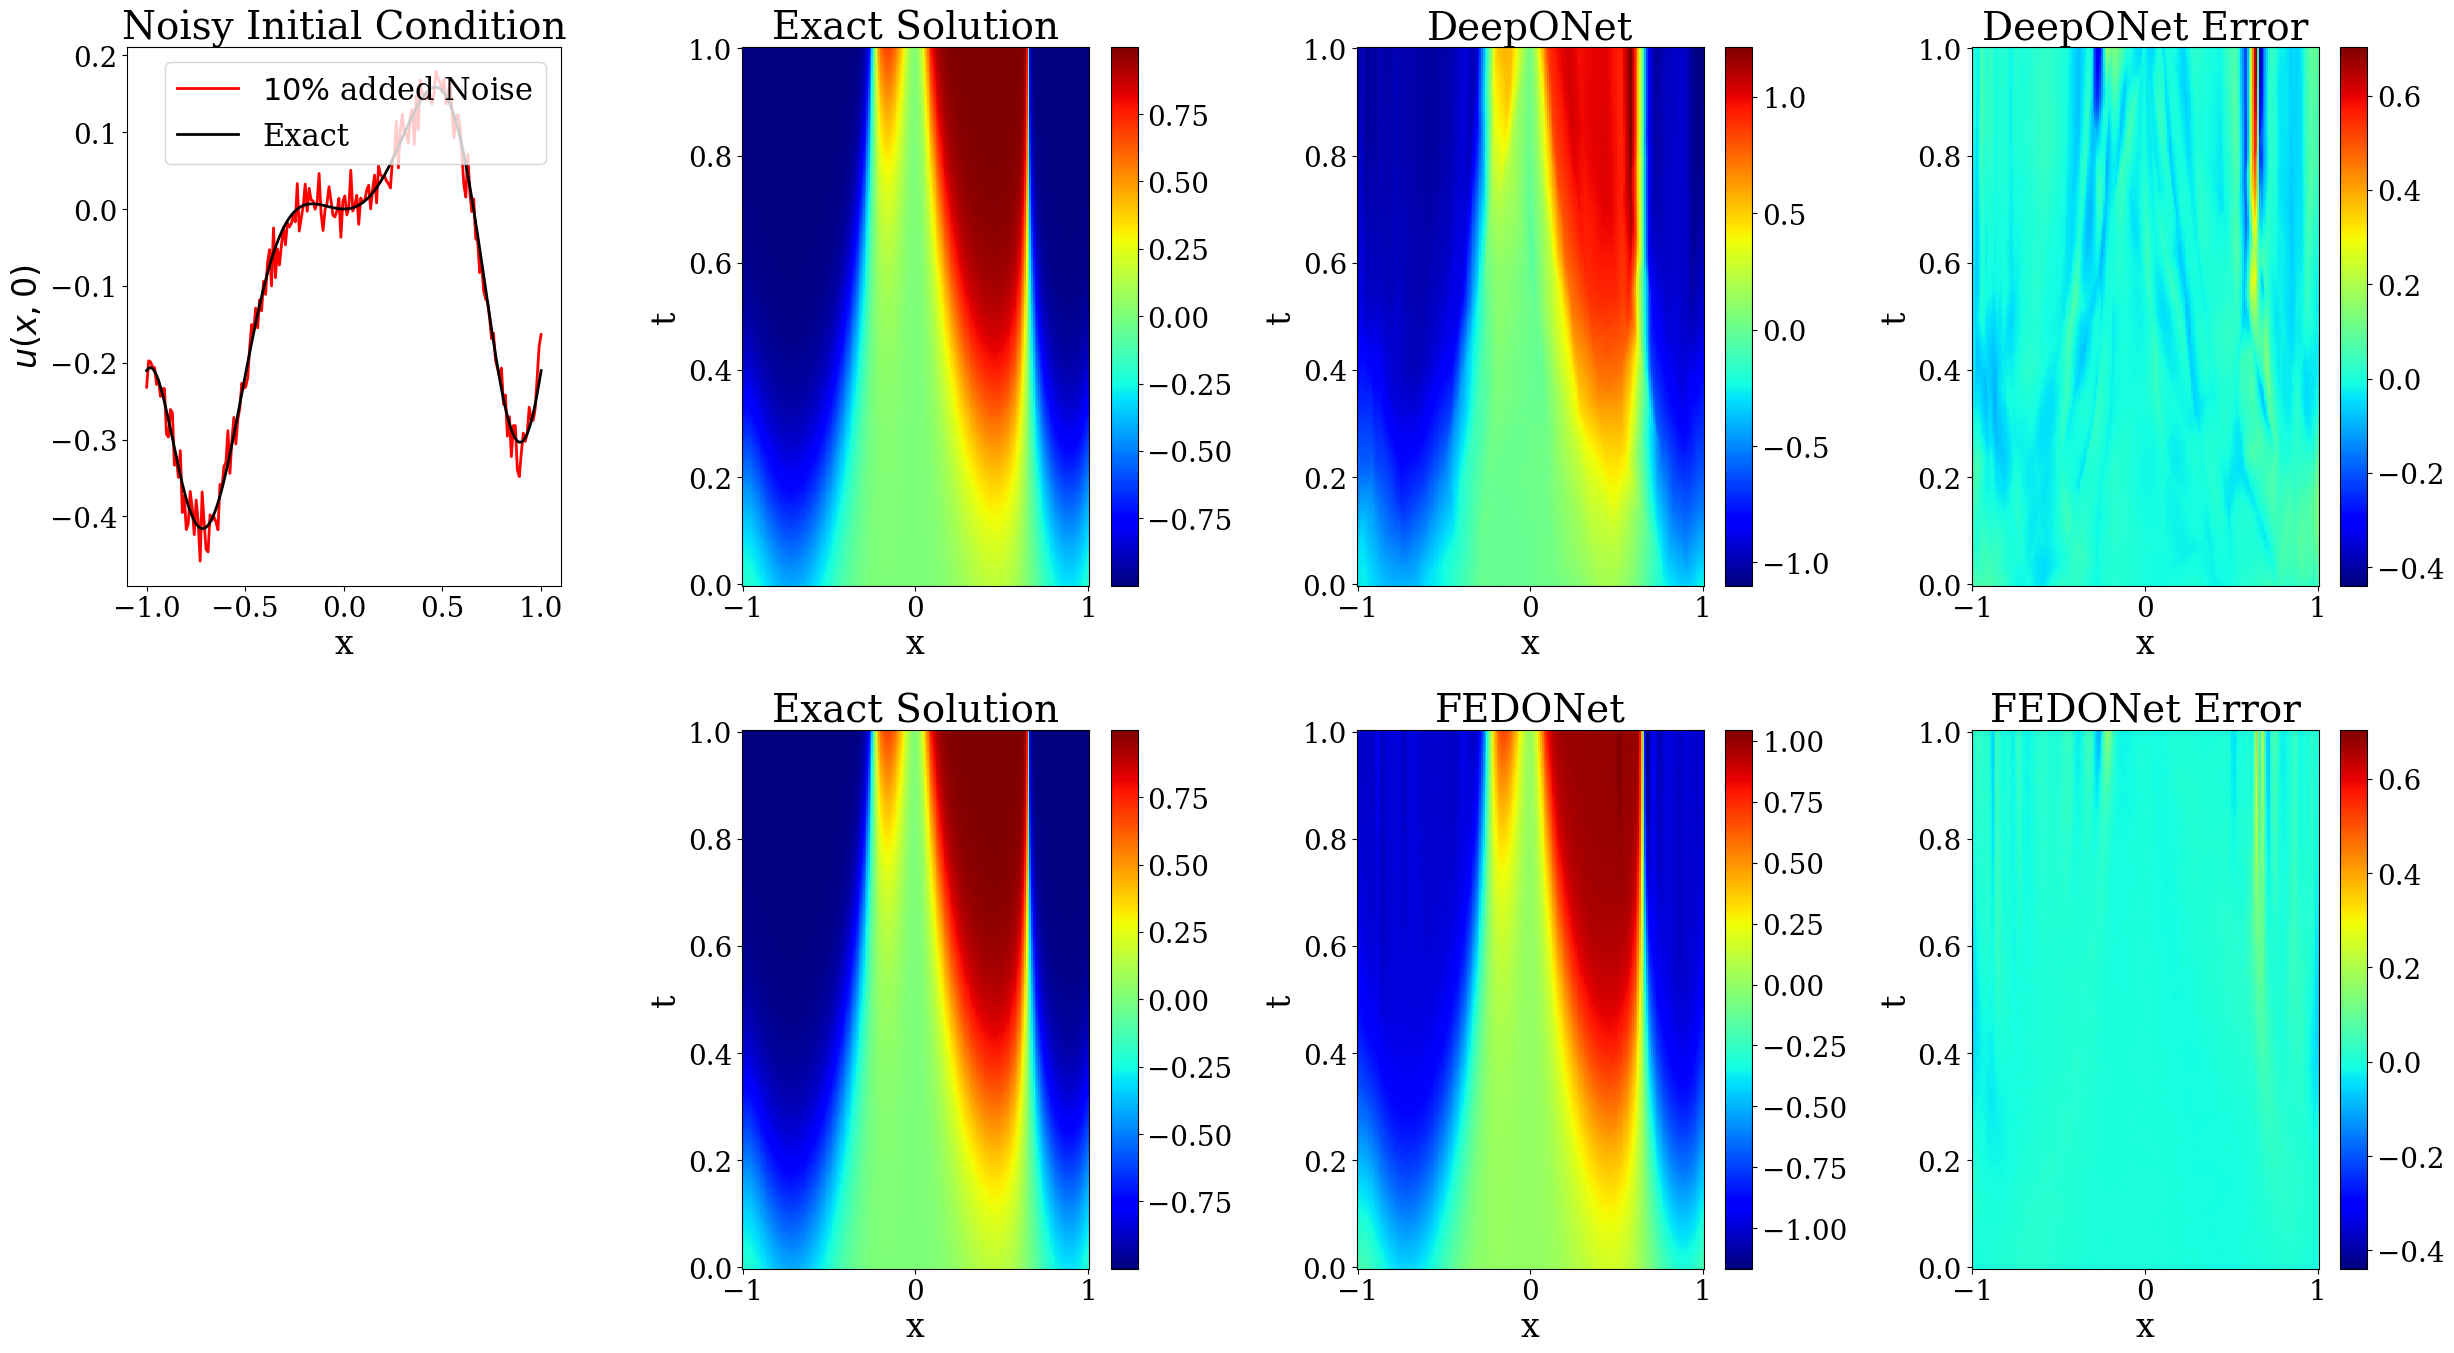

In [3]:
# ============================================================
# NOISE TEST VISUALIZATION (single sample)
# ============================================================

noise_level_vis = 0.10
sample_idx = 0

# ---- Add noise to one clean test IC ----
rms_sample = np.sqrt(np.mean(X_test[sample_idx] ** 2)) + 1e-12
noise_sample = np.random.randn(*X_test[sample_idx].shape) * (noise_level_vis * rms_sample)
X_sample_noisy = X_test[sample_idx] + noise_sample

# ---- Prepare input tensor ----
X_sample_tensor = torch.tensor(X_sample_noisy[None, :], dtype=torch.float32).to(device)

# ---- Predict using noisy IC ----
fedo_model.eval()
vanilla_model.eval()

with torch.no_grad():
    pred_fedo_sample = fedo_model(X_sample_tensor, coords).cpu().numpy()[0]
    pred_vanilla_sample = vanilla_model(X_sample_tensor, coords).cpu().numpy()[0]

# ---- Ground truth ----
true_sample = y_test[sample_idx]

# ---- Relative L2 errors ----
rel_l2_fedo_sample = relative_l2_error_sample(true_sample, pred_fedo_sample)
rel_l2_vanilla_sample = relative_l2_error_sample(true_sample, pred_vanilla_sample)

print(f"FEDONet RelL2  : {rel_l2_fedo_sample:.6f}")
print(f"DeepONet RelL2 : {rel_l2_vanilla_sample:.6f}")

# ---- Data for plotting ----
initial_condition_clean = X_test
initial_condition_noisy = np.copy(X_test)
initial_condition_noisy[sample_idx] = X_sample_noisy

full_solution = y_test

# ---- Grid ----
x = np.linspace(-1, 1, true_sample.shape[0])
t = np.linspace(0, 1, true_sample.shape[1])
XX, TT = np.meshgrid(x, t, indexing='xy')

# ---- Errors ----
error_fed = true_sample - pred_fedo_sample
error_van = true_sample - pred_vanilla_sample

vmin = min(error_fed.min(), error_van.min())
vmax = max(error_fed.max(), error_van.max())

# ============================================================
# Plot
# ============================================================

plt.rcParams.update({
    'font.size': 22,
    'axes.titlesize': 28,
    'axes.labelsize': 24,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'legend.fontsize': 22
})

plt.rcParams['image.cmap'] = 'jet'
fig = plt.figure(figsize=(25, 14))

# ---- Noisy IC ----
plt.subplot(2, 4, 1)
plt.plot(x, initial_condition_noisy[sample_idx], linewidth=2, color='r',
         label=f'${int(100*noise_level_vis)}\\%$ added Noise')
plt.plot(x, initial_condition_clean[sample_idx], linewidth=2, color='k',
         label='Exact')
plt.legend(loc='upper right', frameon=True)
plt.title('Noisy Initial Condition')
plt.xlabel('x')
plt.ylabel('$u(x,0)$')

# ---- Exact Solution (top row) ----
ax1 = fig.add_subplot(2, 4, 2)
c1 = ax1.pcolor(XX, TT, true_sample.T, shading='auto')
ax1.set_title('Exact Solution')
ax1.set_xlabel('x')
ax1.set_ylabel('t')
fig.colorbar(c1, ax=ax1)

# ---- DeepONet Prediction ----
ax2 = fig.add_subplot(2, 4, 3)
c2 = ax2.pcolor(XX, TT, pred_vanilla_sample.T, shading='auto')
ax2.set_title(f'DeepONet')
ax2.set_xlabel('x')
ax2.set_ylabel('t')
fig.colorbar(c2, ax=ax2)

# ---- DeepONet Error ----
ax3 = fig.add_subplot(2, 4, 4)
c3 = ax3.pcolor(XX, TT, error_van.T, vmin=vmin, vmax=vmax, shading='auto')
ax3.set_title('DeepONet Error')
ax3.set_xlabel('x')
ax3.set_ylabel('t')
fig.colorbar(c3, ax=ax3)

# ---- Empty slot to preserve arrangement ----
ax_empty = fig.add_subplot(2, 4, 5)
ax_empty.axis('off')

# ---- Exact Solution (bottom row) ----
ax4 = fig.add_subplot(2, 4, 6)
c4 = ax4.pcolor(XX, TT, true_sample.T, shading='auto')
ax4.set_title('Exact Solution')
ax4.set_xlabel('x')
ax4.set_ylabel('t')
fig.colorbar(c4, ax=ax4)

# ---- FEDONet Prediction ----
ax5 = fig.add_subplot(2, 4, 7)
c5 = ax5.pcolor(XX, TT, pred_fedo_sample.T, shading='auto')
ax5.set_title(f'FEDONet')
ax5.set_xlabel('x')
ax5.set_ylabel('t')
fig.colorbar(c5, ax=ax5)

# ---- FEDONet Error ----
ax6 = fig.add_subplot(2, 4, 8)
c6 = ax6.pcolor(XX, TT, error_fed.T, vmin=vmin, vmax=vmax, shading='auto')
ax6.set_title('FEDONet Error')
ax6.set_xlabel('x')
ax6.set_ylabel('t')
fig.colorbar(c6, ax=ax6)

plt.tight_layout()
plt.show()

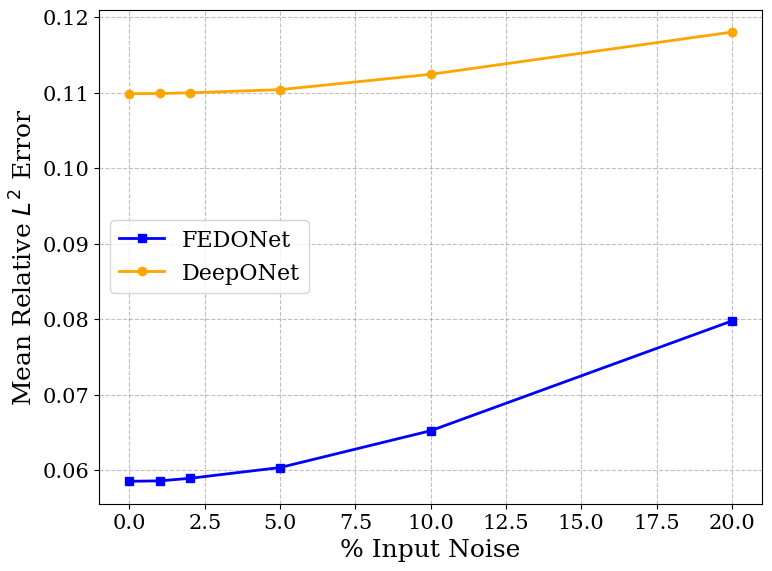

In [6]:
import matplotlib as mpl

def set_plot_params():
    mpl.rcParams['figure.figsize'] = (8, 6)
    mpl.rcParams['figure.dpi'] = 100
    mpl.rcParams['savefig.dpi'] = 300
    mpl.rcParams['font.family'] = 'serif'
    mpl.rcParams['font.size'] = 15
    mpl.rcParams['axes.titlesize'] = 16
    mpl.rcParams['axes.labelsize'] = 14
    mpl.rcParams['xtick.labelsize'] = 12
    mpl.rcParams['ytick.labelsize'] = 12
    mpl.rcParams['legend.fontsize'] = 12
    mpl.rcParams['grid.linestyle'] = '--'
    mpl.rcParams['grid.color'] = 'gray'
    mpl.rcParams['grid.alpha'] = 0.5
    mpl.rcParams['image.cmap'] = 'viridis'

set_plot_params()

plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 21,
    'axes.labelsize': 18,
    'xtick.labelsize': 15,
    'ytick.labelsize': 15,
    'legend.fontsize': 16
})

plt.figure(figsize=(8, 6))

plt.plot(noise_percent, fedo_rel_l2, marker='s', color = 'blue',label='FEDONet')
plt.plot(noise_percent, vanilla_rel_l2, marker='o', color = 'orange', label='DeepONet')

plt.xlabel("% Input Noise")
plt.ylabel("Mean Relative $L^2$ Error")
plt.grid(True)
plt.legend(loc='center left')

plt.tight_layout()
plt.show()

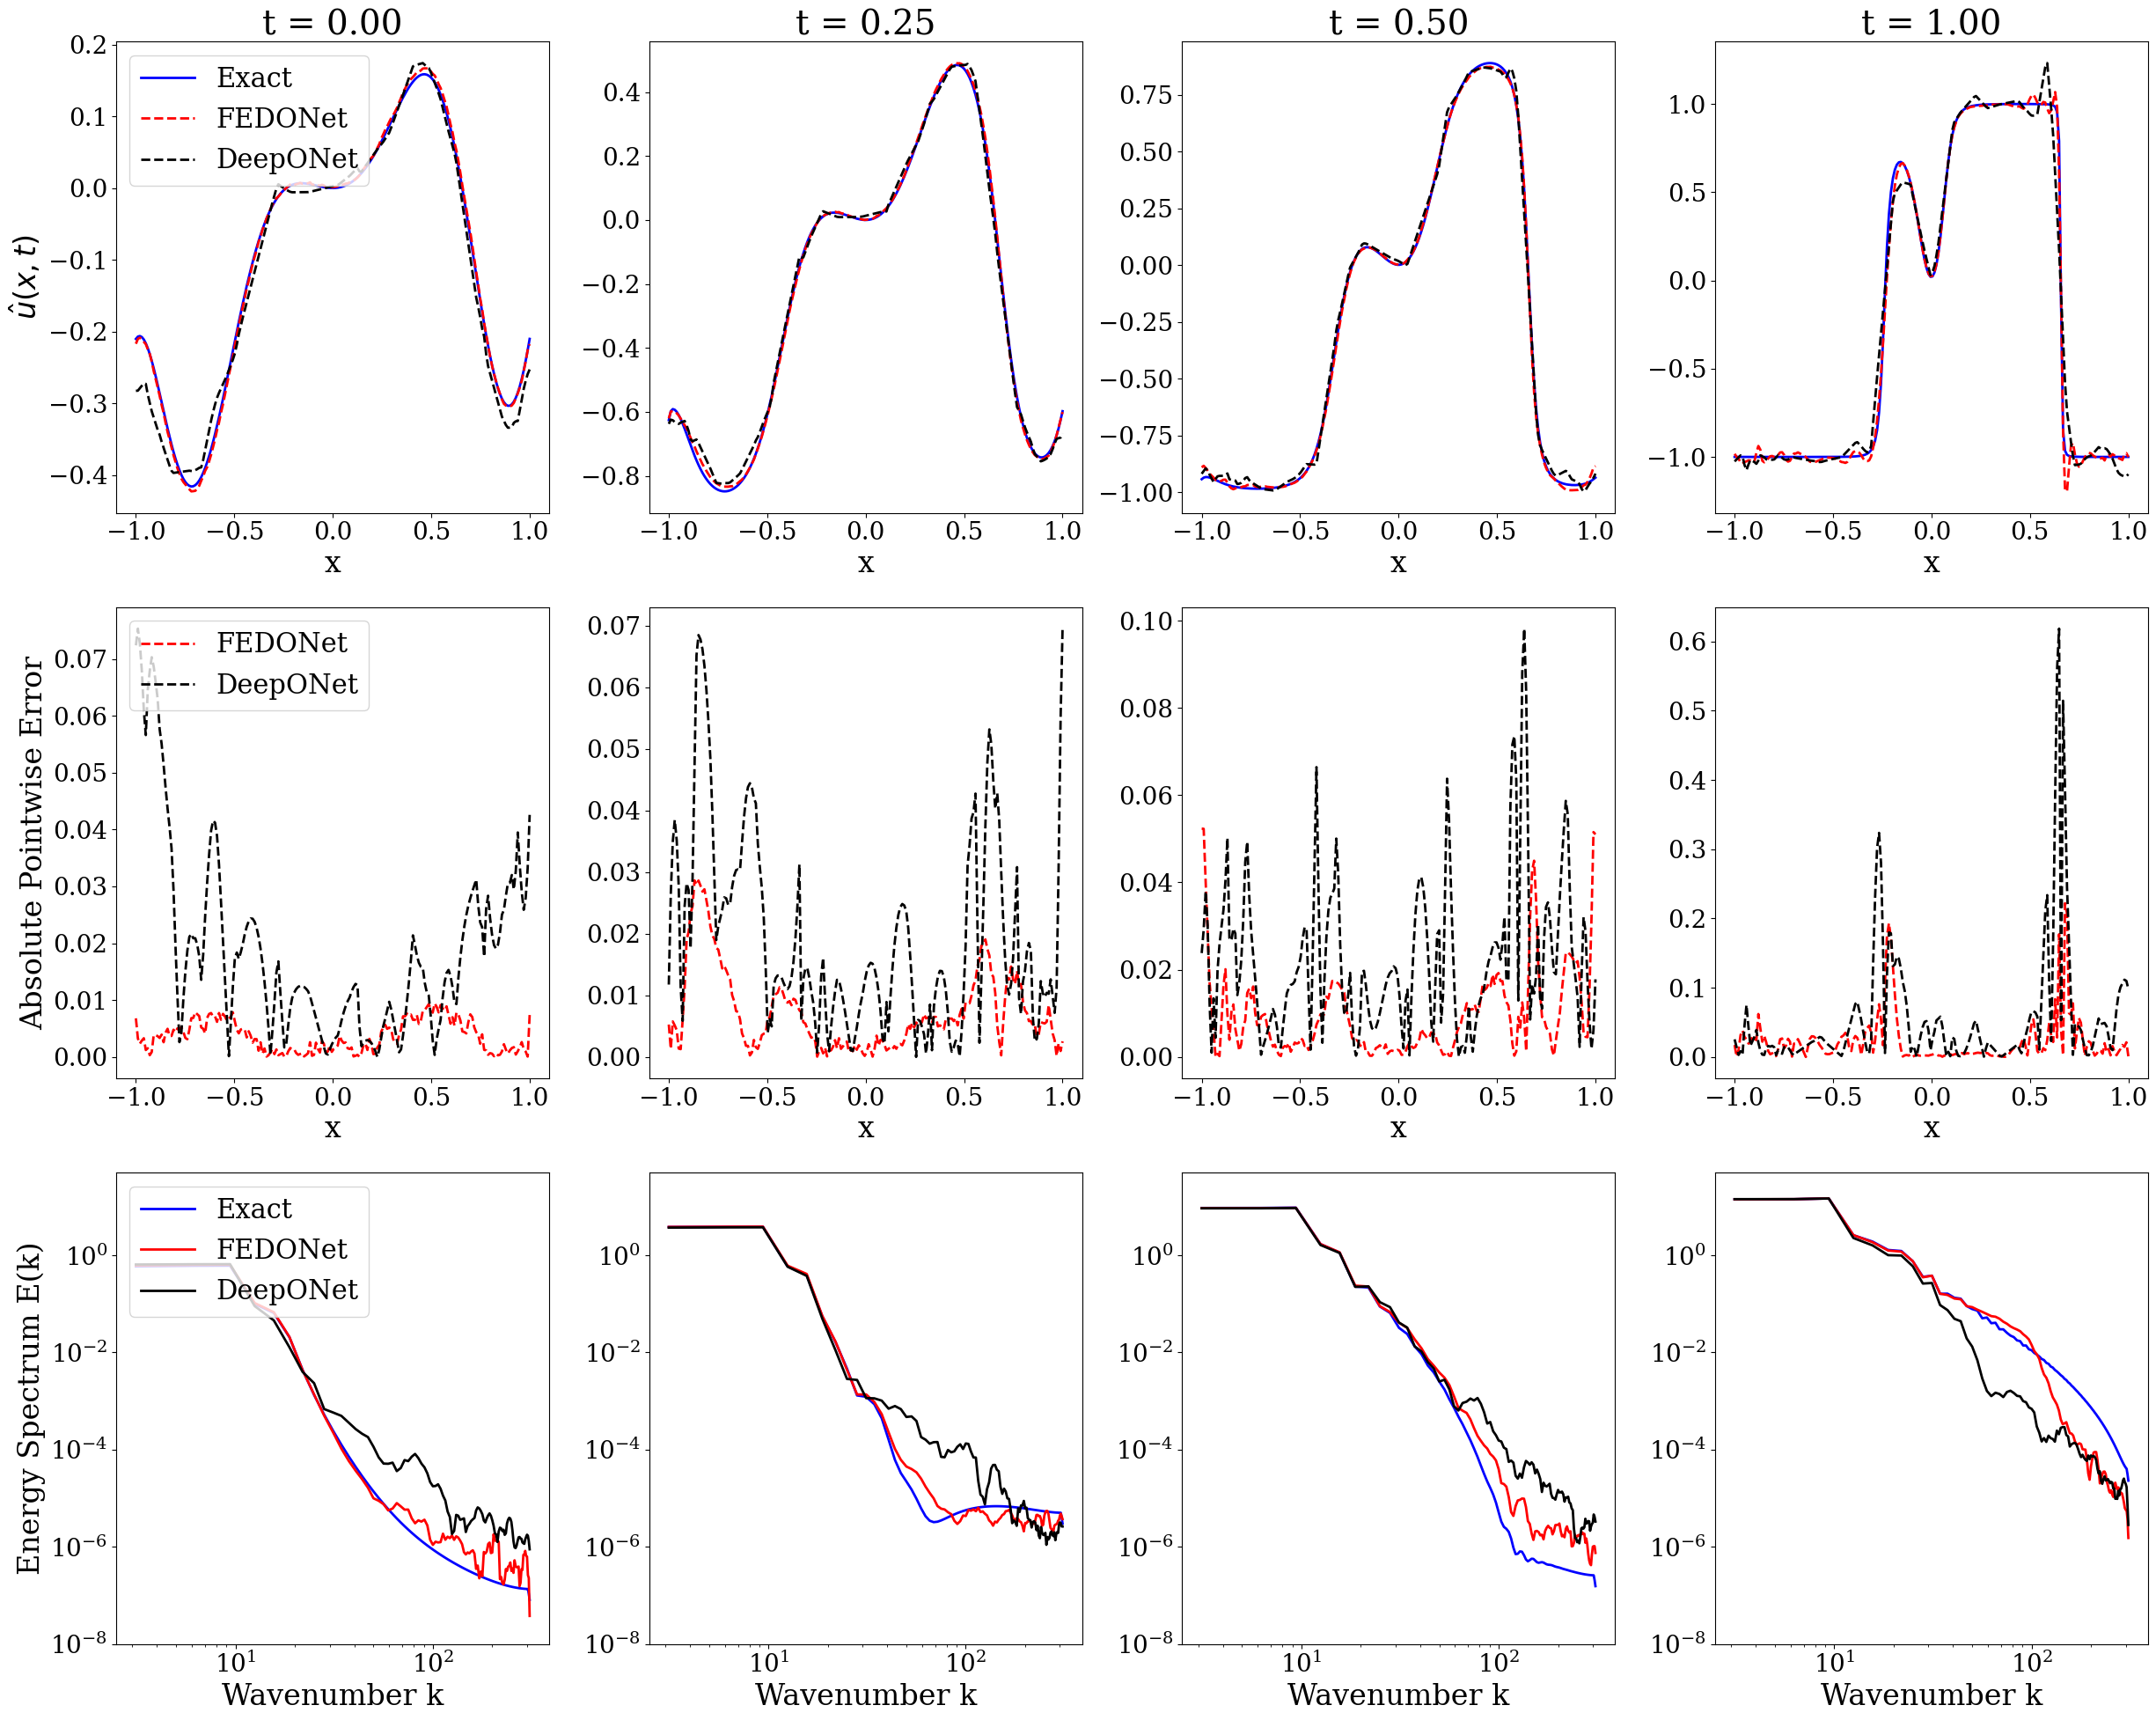

In [5]:
import matplotlib.pyplot as plt
import numpy as np

import numpy as np
import matplotlib.pyplot as plt
# import seaborn as sns

def compute_energy_spectrum(u, x):
    """
    Computes the energy spectrum of a 1D velocity field.

    Parameters:
        u (numpy array): The velocity field.
        x (numpy array): The spatial grid points corresponding to u.

    Returns:
        k_sorted (numpy array): Sorted wavenumbers.
        E_k_sorted (numpy array): Corresponding energy spectrum values.
    """
    N = len(u)  # Number of points
    dx = x[1] - x[0]  # Grid spacing

    u_hat = np.fft.fft(u)  # Compute FFT
    k = np.fft.fftfreq(N, d=dx) * 2 * np.pi  # Compute wavenumbers
    E_k = (np.abs(u_hat)**2) / N  # Compute energy spectrum

    # Sort for visualization
    k_sorted = np.fft.fftshift(k)  
    E_k_sorted = np.fft.fftshift(E_k)

    return k_sorted[N//2+1:], E_k_sorted[N//2+1:]

def smooth_spectrum(Ek, window_len=5):
    """5-point moving average to reduce high-k noise."""
    return np.convolve(Ek, np.ones(window_len)/window_len, mode='same')

# ============================================================
# 0% NOISE COMPARISON: FEDONet vs DeepONet
# 3x4 layout:
#   Row 1 -> solution slices at selected times
#   Row 2 -> absolute pointwise error
#   Row 3 -> energy spectrum
# ============================================================

# ---- No added noise ----
noise_level_vis = 0.0
idx = 0

# ---- Clean input ----
X_clean = X_test.copy()
X_clean_tensor = torch.tensor(X_clean, dtype=torch.float32).to(device)

# ---- Predict on clean input ----
fedo_model.eval()
vanilla_model.eval()

with torch.no_grad():
    outputs_fed = fedo_model(X_clean_tensor, coords).cpu().numpy()
    outputs_van = vanilla_model(X_clean_tensor, coords).cpu().numpy()

full_solution = y_test.copy()

# ============================================================
# Make shapes consistent: want (n_samples, nx, nt)
# ============================================================
def ensure_nx_nt(arr, x_len):
    """
    Convert array to shape (n_samples, nx, nt) if needed.
    Assumes arr is either (n_samples, nx, nt) or (n_samples, nt, nx).
    """
    if arr.ndim != 3:
        raise ValueError(f"Expected 3D array, got shape {arr.shape}")

    if arr.shape[1] == x_len:
        return arr
    elif arr.shape[2] == x_len:
        return np.transpose(arr, (0, 2, 1))
    else:
        raise ValueError(f"Cannot infer x-dimension from shape {arr.shape} with x_len={x_len}")

# ---- Spatial grid ----
x = np.linspace(-1, 1, X_test.shape[1])

# ---- Convert to (n_samples, nx, nt) ----
full_solution = ensure_nx_nt(full_solution, len(x))
outputs_fed   = ensure_nx_nt(outputs_fed,   len(x))
outputs_van   = ensure_nx_nt(outputs_van,   len(x))

# ---- Time grid ----
nt = full_solution.shape[2]
t = np.linspace(0, 1, nt)

# ---- Choose time slices robustly ----
time_indices = [0, nt // 4, nt // 2, nt - 1]
titles = [f't = {t[i]:.2f}' for i in time_indices]

# ============================================================
# Plot params
# ============================================================

# Increase only font sizes


set_plot_params()

plt.rcParams.update({
    'font.size': 22,
    'axes.titlesize': 28,
    'axes.labelsize': 24,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'legend.fontsize': 22
})
fig, axes = plt.subplots(3, 4, figsize=(25, 20))

# ============================================================
# Row 1: Solution comparison
# ============================================================
for i, t_idx in enumerate(time_indices):
    ax = axes[0, i]

    ax.plot(x, full_solution[idx, :, t_idx].squeeze(),
            linewidth=2, color='b', label='Exact')
    ax.plot(x, outputs_fed[idx, :, t_idx].squeeze(),
            linewidth=2, color='red', linestyle='--', label='FEDONet')
    ax.plot(x, outputs_van[idx, :, t_idx].squeeze(),
            linewidth=2, color='k', linestyle='--', label='DeepONet')

    ax.set_xlabel('x')
    ax.set_title(titles[i])

    if i == 0:
        ax.set_ylabel(r'$\hat{u}(x,t)$')
        ax.legend(loc='upper left')

# ============================================================
# Row 2: Absolute pointwise error
# ============================================================
for i, t_idx in enumerate(time_indices):
    ax = axes[1, i]

    ax.plot(
        x,
        np.abs(full_solution[idx, :, t_idx].squeeze() - outputs_fed[idx, :, t_idx].squeeze()),
        linewidth=2, color='red', linestyle='--', label='FEDONet'
    )
    ax.plot(
        x,
        np.abs(full_solution[idx, :, t_idx].squeeze() - outputs_van[idx, :, t_idx].squeeze()),
        linewidth=2, color='k', linestyle='--', label='DeepONet'
    )

    ax.set_xlabel('x')

    if i == 0:
        ax.set_ylabel('Absolute Pointwise Error')
        ax.legend(loc='upper left')

# ============================================================
# Row 3: Energy spectra
# ============================================================
for i, t_idx in enumerate(time_indices):
    ax = axes[2, i]

    k_vals, E_vals = compute_energy_spectrum(
        full_solution[idx, :, t_idx].squeeze(), x
    )
    k_vals_van, E_vals_van = compute_energy_spectrum(
        outputs_van[idx, :, t_idx].squeeze(), x
    )
    k_vals_fed, E_vals_fed = compute_energy_spectrum(
        outputs_fed[idx, :, t_idx].squeeze(), x
    )

    ax.loglog(k_vals,     smooth_spectrum(E_vals),     'b-', label='Exact')
    ax.loglog(k_vals_fed, smooth_spectrum(E_vals_fed), 'r-', label='FEDONet')
    ax.loglog(k_vals_van, smooth_spectrum(E_vals_van), 'k-', label='DeepONet')

    ax.set_xlabel('Wavenumber k')

    if i == 0:
        ax.set_ylabel('Energy Spectrum E(k)')

    ax.set_ylim([1e-8, 50])

axes[2, 0].legend(loc='upper left')
plt.tight_layout()
plt.show()